## EN3160-Fundamentals of Image Processing and Computer Vision

## Assignment 01 - <br> Intensity Transformations and Neighborhood Filtering

**Name:** Bandara H.Y.W.  <br>
**Index Number:** 230074J <br>
**GitHub:** 

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def show_bgr(ax, img, title):
    ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')

### Question 1 - Piecewise Linear Intensity Transformation

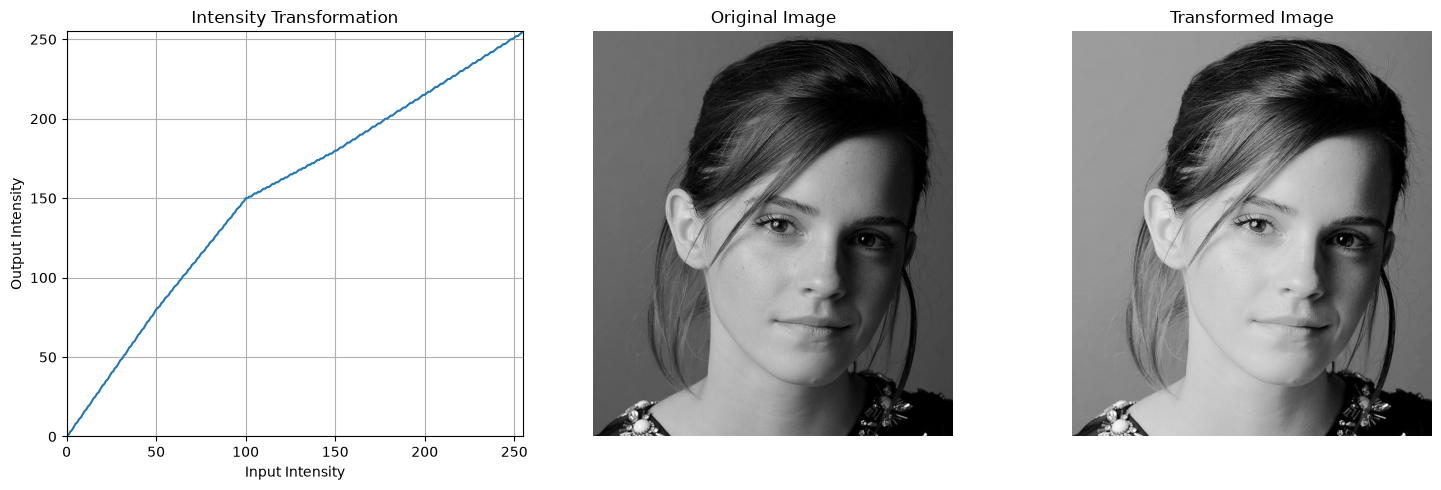

In [19]:
im = cv.imread('images/fig1b_intensity_image.jpg',cv.IMREAD_GRAYSCALE)

assert im is not None, "Image could not be loaded."

def intensity_transform(im, breakpoints):

    bp = np.asarray(breakpoints, dtype=np.float32)

    x = bp[:, 0]
    y = bp[:, 1]

    lut = np.zeros(256, dtype=np.float32)

    for r in range(256):

        if r <= x[0]:
            lut[r] = y[0]

        elif r >= x[-1]:
            lut[r] = y[-1]

        else:
            k = np.searchsorted(x, r, side='right') - 1

            x1 = x[k];     y1 = y[k]
            x2 = x[k + 1]; y2 = y[k + 1]
            
            lut[r] = y1 + ((r-x1)*(y2-y1)/(x2-x1))

    lut = np.clip(lut,0,255).astype(np.uint8)
    transformed = cv.LUT(im, lut)

    return transformed, lut


breakpoints = np.array([
    [0,   0],
    [50,  80],
    [100, 150],
    [150, 180],
    [255, 255]
])



transformed, lut = intensity_transform(im,breakpoints)


fig, ax = plt.subplots(1,3,figsize=(15, 5))



ax[0].plot(np.arange(256),lut)
ax[0].set_title('Intensity Transformation')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim(0,255)
ax[0].set_ylim(0,255)
ax[0].grid()

ax[1].imshow(im,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(transformed,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()




### Question 2 - Accentuating White Matter and Gray Matter

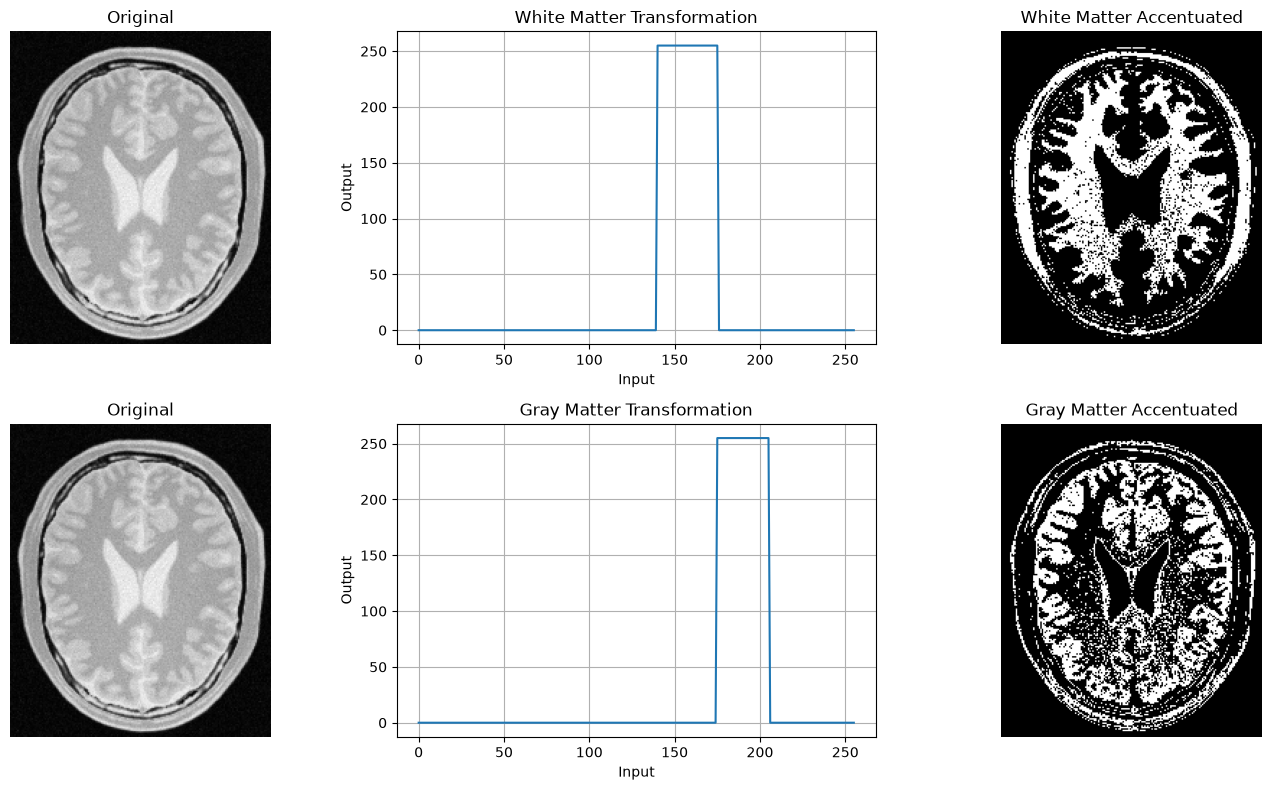

In [21]:
brain = cv.imread('images/fig2_brain_proton_density.png', cv.IMREAD_GRAYSCALE)
assert brain is not None, "Image could not be loaded."


# white_bp = np.array([[0,0], [145,30], [160,80], [180,230], [200,245], [255,255]])
# gray_bp  = np.array([[0,0], [165,30], [180,70], [210,235], [225,245], [255,255]])

white_bp = np.array([[0,0], [139,0], [140,255], [175,255], [176,0], [255,0]])
gray_bp = np.array([[0,0], [174,0], [175,255], [205,255], [206,0], [255,0]])

white_img, white_lut = intensity_transform(brain, white_bp)
gray_img, gray_lut = intensity_transform(brain, gray_bp)

fig, ax = plt.subplots(2, 3, figsize=(15,8))

ax[0,0].imshow(brain, cmap='gray', vmin=0, vmax=255)
ax[0,0].set_title('Original')
ax[0,0].axis('off')
ax[0,1].plot(np.arange(256), white_lut)
ax[0,1].set_title('White Matter Transformation');
ax[0,1].set_xlabel('Input') 
ax[0,1].set_ylabel('Output')
ax[0,1].grid()
ax[0,2].imshow(white_img, cmap='gray', vmin=0, vmax=255)
ax[0,2].set_title('White Matter Accentuated')
ax[0,2].axis('off')

ax[1,0].imshow(brain, cmap='gray', vmin=0, vmax=255)
ax[1,0].set_title('Original')
ax[1,0].axis('off')
ax[1,1].plot(np.arange(256), gray_lut)
ax[1,1].set_title('Gray Matter Transformation')
ax[1,1].set_xlabel('Input')
ax[1,1].set_ylabel('Output'); ax[1,1].grid()
ax[1,2].imshow(gray_img, cmap='gray', vmin=0, vmax=255)
ax[1,2].set_title('Gray Matter Accentuated')
ax[1,2].axis('off')

plt.tight_layout()
plt.show()

### Question 3 - Gamma Correction

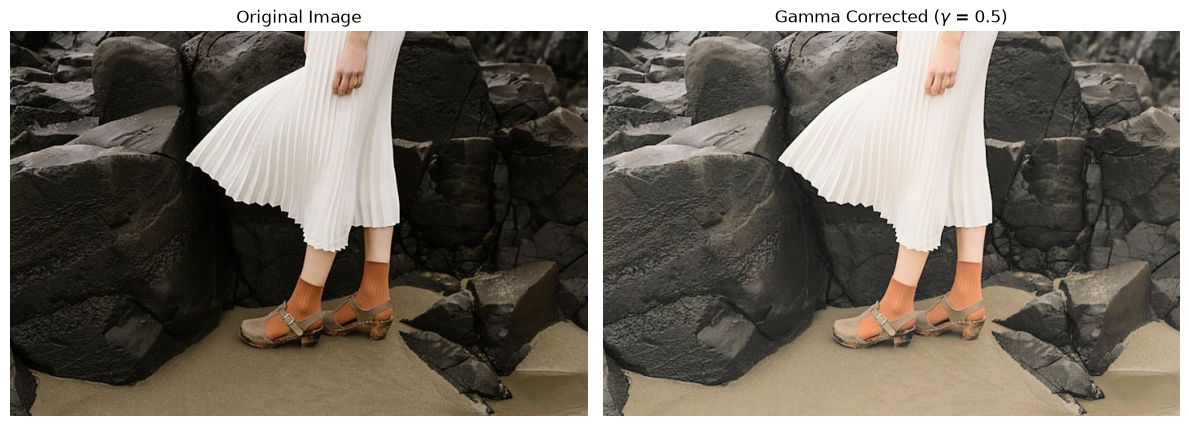

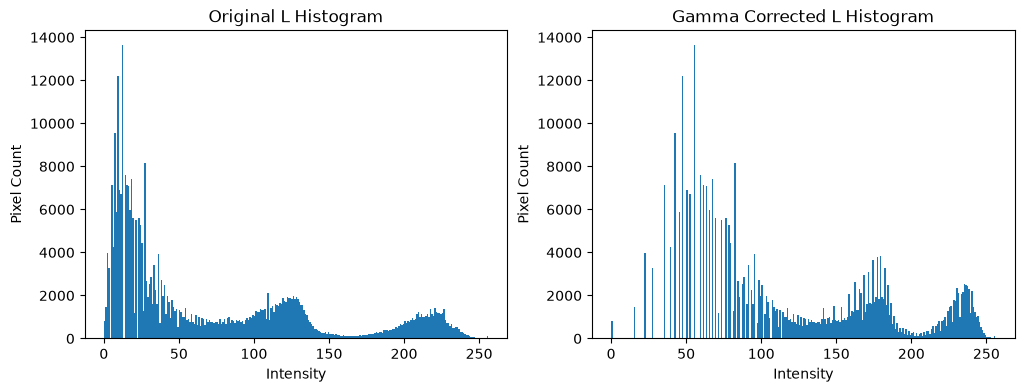

In [31]:
im = cv.imread('images/fig3_gamma_correction.jpg')
assert im is not None, "Image could not be loaded."

lab = cv.cvtColor(im, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)


gamma = 0.5
L_normalized = L.astype(np.float32) / 255.0
L_corrected = 255 * (L_normalized ** gamma)
L_corrected = np.clip(L_corrected, 0, 255).astype(np.uint8)


lab_corrected = cv.merge([L_corrected, a, b])
corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)


fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB));
ax[0].set_title('Original Image');
ax[0].axis('off')
ax[1].imshow(cv.cvtColor(corrected, cv.COLOR_BGR2RGB));
ax[1].set_title(f'Gamma Corrected ($\\gamma$ = {gamma})');
ax[1].axis('off')
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(L.ravel(), bins=256, range=(0,256));
ax[0].set_title('Original L Histogram');
ax[0].set_xlabel('Intensity');
ax[0].set_ylabel('Pixel Count')
ax[1].hist(L_corrected.ravel(), bins=256, range=(0,256));
ax[1].set_title('Gamma Corrected L Histogram');
ax[1].set_xlabel('Intensity');
ax[1].set_ylabel('Pixel Count')
plt.show()

### Question 4 - Vibrance Enhancement

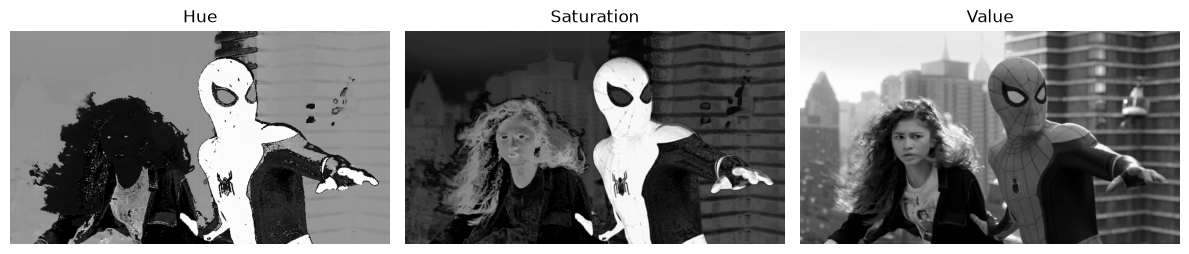

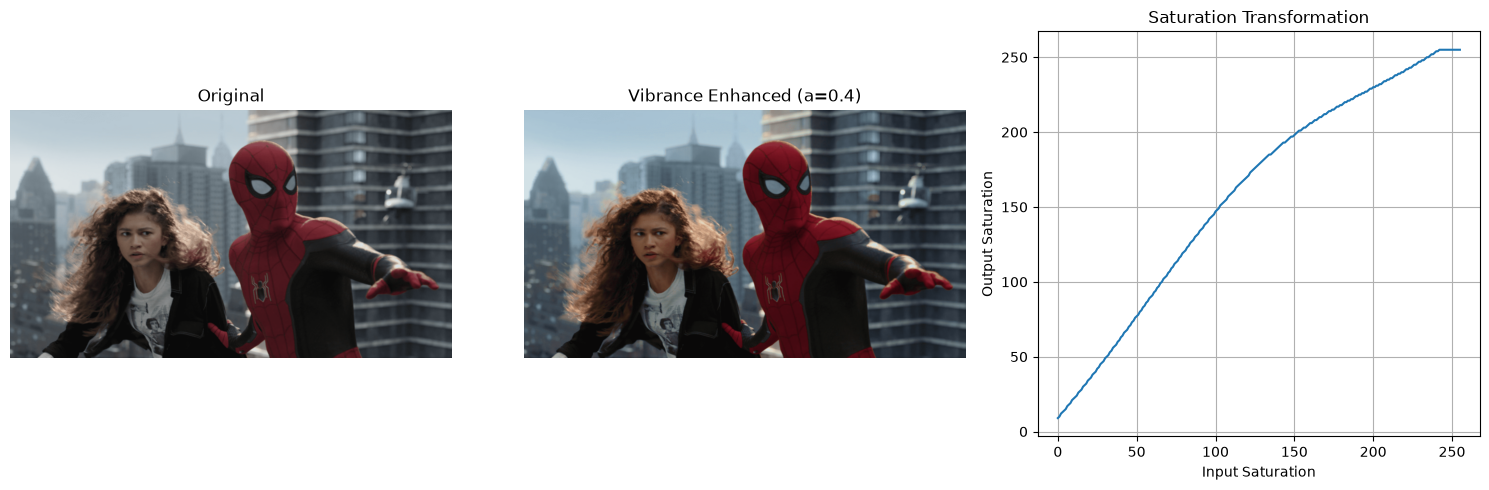

In [ ]:
im = cv.imread('images/fig4_vibrance.png')
assert im is not None, "Image could not be loaded."

hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

a_value = 0.4
sigma = 70

x = np.arange(256, dtype=np.float32)
transform = x + a_value * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2))
transform = np.minimum(transform, 255).astype(np.uint8)

S_new = transform[S]

hsv_new = cv.merge([H, S_new, V])
vibrant = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)

fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].imshow(H, cmap='gray')
ax[0].set_title('Hue')
ax[0].axis('off')
ax[1].imshow(S, cmap='gray')
ax[1].set_title('Saturation')
ax[1].axis('off')
ax[2].imshow(V, cmap='gray')
ax[2].set_title('Value')
ax[2].axis('off')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(vibrant, cv.COLOR_BGR2RGB))
ax[1].set_title(f'Vibrance Enhanced (a={a_value})')
ax[1].axis('off')
ax[2].plot(x, transform); ax[2].set_title('Saturation Transformation')
ax[2].set_xlabel('Input Saturation')
ax[2].set_ylabel('Output Saturation')
ax[2].grid()
plt.tight_layout()
plt.show()

### Question 5 - Histogram Equalization

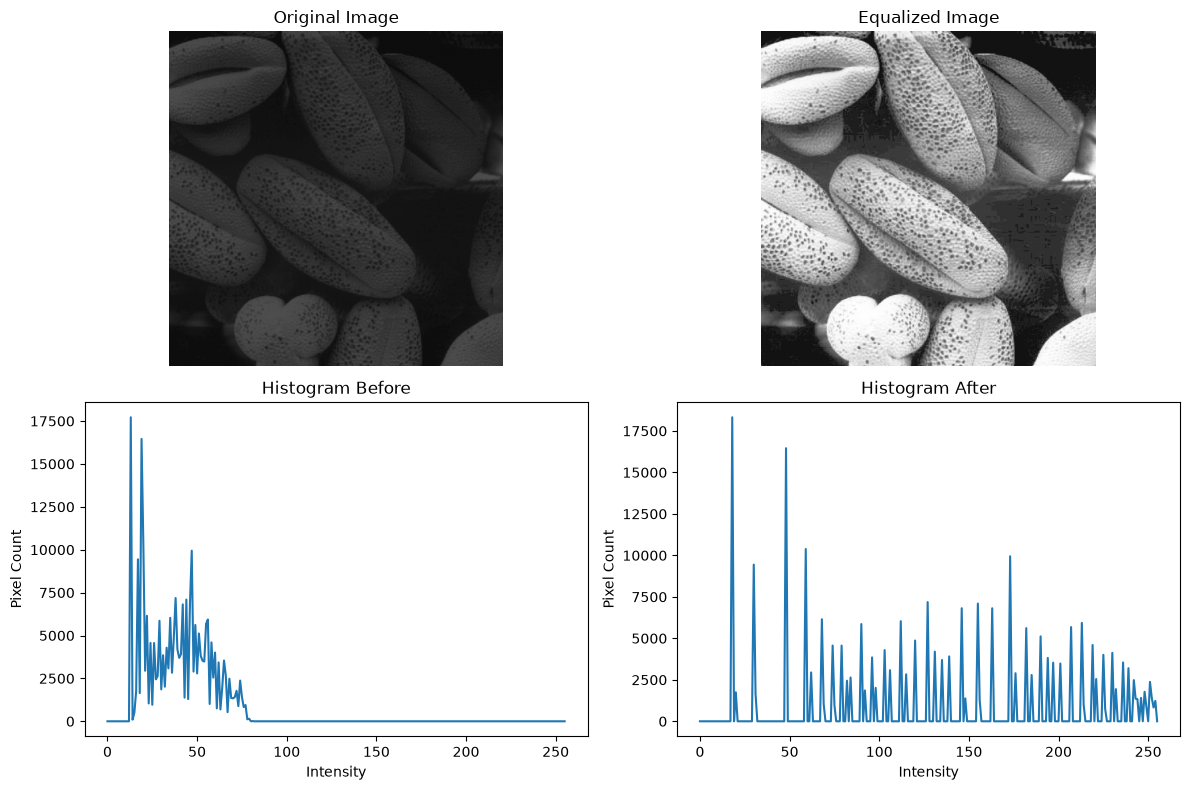

In [37]:
im = cv.imread('images/fig5_histogram_equalization.png', cv.IMREAD_GRAYSCALE)
assert im is not None, "Image could not be loaded."

def my_hist_equalization(im):
    hist = np.bincount(im.ravel(), minlength=256)
    cdf = np.cumsum(hist)
    M, N = im.shape
    lut = ((255 / (M * N)) * cdf).astype(np.uint8)
    result = lut[im]
    return result, hist, cdf, lut

equalized, hist_before, cdf, lut = my_hist_equalization(im)
hist_after = np.bincount(equalized.ravel(), minlength=256)

fig, ax = plt.subplots(2, 2, figsize=(12,8))
ax[0,0].imshow(im, cmap='gray', vmin=0, vmax=255); ax[0,0].set_title('Original Image'); ax[0,0].axis('off')
ax[0,1].imshow(equalized, cmap='gray', vmin=0, vmax=255); ax[0,1].set_title('Equalized Image'); ax[0,1].axis('off')
ax[1,0].plot(hist_before); ax[1,0].set_title('Histogram Before'); ax[1,0].set_xlabel('Intensity'); ax[1,0].set_ylabel('Pixel Count')
ax[1,1].plot(hist_after); ax[1,1].set_title('Histogram After'); ax[1,1].set_xlabel('Intensity'); ax[1,1].set_ylabel('Pixel Count')
plt.tight_layout()
plt.show()